In [105]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/divyanths/beneficiary-data/Train_Beneficiarydata-1542865627584.csv


In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully")

Libraries imported successfully


In [107]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if 'Beneficiary' in filename:
            print(os.path.join(dirname, filename))

/kaggle/input/datasets/divyanths/beneficiary-data/Train_Beneficiarydata-1542865627584.csv


In [108]:
beneficiary_path = "/kaggle/input/datasets/divyanths/beneficiary-data/Train_Beneficiarydata-1542865627584.csv"

beneficiary_df = pd.read_csv(beneficiary_path)

print("Dataset loaded successfully!")
print("Shape:", beneficiary_df.shape)

Dataset loaded successfully!
Shape: (138556, 25)


In [109]:
beneficiary_df.head()

,BeneID,DOB,DOD,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,...,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt
0,BENE11001,1943-01-01,NaN,1,1,0,39,230,12,12,...,1,1,1,2,1,1,36000,3204,60,70
1,BENE11002,1936-09-01,NaN,2,1,0,39,280,12,12,...,2,2,2,2,2,2,0,0,30,50
2,BENE11003,1936-08-01,NaN,1,1,0,52,590,12,12,...,2,2,1,2,2,2,0,0,90,40
3,BENE11004,1922-07-01,NaN,1,1,0,39,270,12,12,...,2,1,1,1,1,2,0,0,1810,760
4,BENE11005,1935-09-01,NaN,1,1,0,24,680,12,12,...,2,1,2,2,2,2,0,0,1790,1200


In [110]:
beneficiary_df.columns.tolist()

['BeneID',
 'DOB',
 'DOD',
 'Gender',
 'Race',
 'RenalDiseaseIndicator',
 'State',
 'County',
 'NoOfMonths_PartACov',
 'NoOfMonths_PartBCov',
 'ChronicCond_Alzheimer',
 'ChronicCond_Heartfailure',
 'ChronicCond_KidneyDisease',
 'ChronicCond_Cancer',
 'ChronicCond_ObstrPulmonary',
 'ChronicCond_Depression',
 'ChronicCond_Diabetes',
 'ChronicCond_IschemicHeart',
 'ChronicCond_Osteoporasis',
 'ChronicCond_rheumatoidarthritis',
 'ChronicCond_stroke',
 'IPAnnualReimbursementAmt',
 'IPAnnualDeductibleAmt',
 'OPAnnualReimbursementAmt',
 'OPAnnualDeductibleAmt']

In [111]:
beneficiary_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138556 entries, 0 to 138555
Data columns (total 25 columns):
 #   Column                           Non-Null Count   Dtype 
---  ------                           --------------   ----- 
 0   BeneID                           138556 non-null  object
 1   DOB                              138556 non-null  object
 2   DOD                              1421 non-null    object
 3   Gender                           138556 non-null  int64 
 4   Race                             138556 non-null  int64 
 5   RenalDiseaseIndicator            138556 non-null  object
 6   State                            138556 non-null  int64 
 7   County                           138556 non-null  int64 
 8   NoOfMonths_PartACov              138556 non-null  int64 
 9   NoOfMonths_PartBCov              138556 non-null  int64 
 10  ChronicCond_Alzheimer            138556 non-null  int64 
 11  ChronicCond_Heartfailure         138556 non-null  int64 
 12  ChronicCond_Kidn

In [112]:
beneficiary_df.isnull().sum()

BeneID                                  0
DOB                                     0
DOD                                137135
Gender                                  0
Race                                    0
RenalDiseaseIndicator                   0
State                                   0
County                                  0
NoOfMonths_PartACov                     0
NoOfMonths_PartBCov                     0
ChronicCond_Alzheimer                   0
ChronicCond_Heartfailure                0
ChronicCond_KidneyDisease               0
ChronicCond_Cancer                      0
ChronicCond_ObstrPulmonary              0
ChronicCond_Depression                  0
ChronicCond_Diabetes                    0
ChronicCond_IschemicHeart               0
ChronicCond_Osteoporasis                0
ChronicCond_rheumatoidarthritis         0
ChronicCond_stroke                      0
IPAnnualReimbursementAmt                0
IPAnnualDeductibleAmt                   0
OPAnnualReimbursementAmt          

In [113]:
beneficiary_df.nunique()

BeneID                             138556
DOB                                   900
DOD                                    11
Gender                                  2
Race                                    4
RenalDiseaseIndicator                   2
State                                  52
County                                314
NoOfMonths_PartACov                    13
NoOfMonths_PartBCov                    13
ChronicCond_Alzheimer                   2
ChronicCond_Heartfailure                2
ChronicCond_KidneyDisease               2
ChronicCond_Cancer                      2
ChronicCond_ObstrPulmonary              2
ChronicCond_Depression                  2
ChronicCond_Diabetes                    2
ChronicCond_IschemicHeart               2
ChronicCond_Osteoporasis                2
ChronicCond_rheumatoidarthritis         2
ChronicCond_stroke                      2
IPAnnualReimbursementAmt             3004
IPAnnualDeductibleAmt                 147
OPAnnualReimbursementAmt          

In [114]:
beneficiary_df.columns.tolist()

['BeneID',
 'DOB',
 'DOD',
 'Gender',
 'Race',
 'RenalDiseaseIndicator',
 'State',
 'County',
 'NoOfMonths_PartACov',
 'NoOfMonths_PartBCov',
 'ChronicCond_Alzheimer',
 'ChronicCond_Heartfailure',
 'ChronicCond_KidneyDisease',
 'ChronicCond_Cancer',
 'ChronicCond_ObstrPulmonary',
 'ChronicCond_Depression',
 'ChronicCond_Diabetes',
 'ChronicCond_IschemicHeart',
 'ChronicCond_Osteoporasis',
 'ChronicCond_rheumatoidarthritis',
 'ChronicCond_stroke',
 'IPAnnualReimbursementAmt',
 'IPAnnualDeductibleAmt',
 'OPAnnualReimbursementAmt',
 'OPAnnualDeductibleAmt']

In [115]:
beneficiary_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138556 entries, 0 to 138555
Data columns (total 25 columns):
 #   Column                           Non-Null Count   Dtype 
---  ------                           --------------   ----- 
 0   BeneID                           138556 non-null  object
 1   DOB                              138556 non-null  object
 2   DOD                              1421 non-null    object
 3   Gender                           138556 non-null  int64 
 4   Race                             138556 non-null  int64 
 5   RenalDiseaseIndicator            138556 non-null  object
 6   State                            138556 non-null  int64 
 7   County                           138556 non-null  int64 
 8   NoOfMonths_PartACov              138556 non-null  int64 
 9   NoOfMonths_PartBCov              138556 non-null  int64 
 10  ChronicCond_Alzheimer            138556 non-null  int64 
 11  ChronicCond_Heartfailure         138556 non-null  int64 
 12  ChronicCond_Kidn

In [116]:
beneficiary_df.isnull().sum()

BeneID                                  0
DOB                                     0
DOD                                137135
Gender                                  0
Race                                    0
RenalDiseaseIndicator                   0
State                                   0
County                                  0
NoOfMonths_PartACov                     0
NoOfMonths_PartBCov                     0
ChronicCond_Alzheimer                   0
ChronicCond_Heartfailure                0
ChronicCond_KidneyDisease               0
ChronicCond_Cancer                      0
ChronicCond_ObstrPulmonary              0
ChronicCond_Depression                  0
ChronicCond_Diabetes                    0
ChronicCond_IschemicHeart               0
ChronicCond_Osteoporasis                0
ChronicCond_rheumatoidarthritis         0
ChronicCond_stroke                      0
IPAnnualReimbursementAmt                0
IPAnnualDeductibleAmt                   0
OPAnnualReimbursementAmt          

In [117]:
beneficiary_df.nunique()

BeneID                             138556
DOB                                   900
DOD                                    11
Gender                                  2
Race                                    4
RenalDiseaseIndicator                   2
State                                  52
County                                314
NoOfMonths_PartACov                    13
NoOfMonths_PartBCov                    13
ChronicCond_Alzheimer                   2
ChronicCond_Heartfailure                2
ChronicCond_KidneyDisease               2
ChronicCond_Cancer                      2
ChronicCond_ObstrPulmonary              2
ChronicCond_Depression                  2
ChronicCond_Diabetes                    2
ChronicCond_IschemicHeart               2
ChronicCond_Osteoporasis                2
ChronicCond_rheumatoidarthritis         2
ChronicCond_stroke                      2
IPAnnualReimbursementAmt             3004
IPAnnualDeductibleAmt                 147
OPAnnualReimbursementAmt          

In [118]:
categorical_cols = [
    'Gender',
    'Race',
    'RenalDiseaseIndicator',
    'State',
    'County',
    'ChronicCond_Alzheimer',
    'ChronicCond_Heartfailure',
    'ChronicCond_KidneyDisease',
    'ChronicCond_Cancer',
    'ChronicCond_ObstrPulmonary',
    'ChronicCond_Depression',
    'ChronicCond_Diabetes',
    'ChronicCond_IschemicHeart',
    'ChronicCond_Osteoporasis',
    'ChronicCond_rheumatoidarthritis',
    'ChronicCond_stroke'
]

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(beneficiary_df[col].value_counts(dropna=False))


--- Gender ---
Gender
2    79106
1    59450
Name: count, dtype: int64

--- Race ---
Race
1    117057
2     13538
3      5059
5      2902
Name: count, dtype: int64

--- RenalDiseaseIndicator ---
RenalDiseaseIndicator
0    118978
Y     19578
Name: count, dtype: int64

--- State ---
State
5     12052
10     9771
45     8780
33     8443
39     6055
14     5923
36     5366
23     5293
34     4629
31     4124
11     3892
49     3623
44     3390
22     3306
15     3272
26     3108
50     2793
52     2662
1      2615
21     2570
42     2524
18     2519
3      2395
24     2165
19     1998
37     1926
4      1817
6      1807
16     1746
25     1622
7      1602
38     1468
17     1339
54     1237
51     1212
20      931
28      905
32      895
46      851
29      752
30      732
13      687
27      538
12      484
43      465
41      438
8       415
47      410
35      304
53      295
9       214
2       196
Name: count, dtype: int64

--- County ---
County
200    3943
10     3587
20     3176
60 

In [119]:
print("DOB sample:")
print(beneficiary_df['DOB'].head(10))

print("\nDOD non-null sample:")
print(beneficiary_df['DOD'].dropna().head(10))

DOB sample:
0    1943-01-01
1    1936-09-01
2    1936-08-01
3    1922-07-01
4    1935-09-01
5    1976-09-01
6    1940-09-01
7    1934-02-01
8    1929-06-01
9    1936-07-01
Name: DOB, dtype: object

DOD non-null sample:
6      2009-12-01
206    2009-09-01
207    2009-09-01
219    2009-05-01
525    2009-12-01
629    2009-07-01
692    2009-12-01
731    2009-08-01
810    2009-10-01
825    2009-05-01
Name: DOD, dtype: object


In [120]:
beneficiary_df[['DOB', 'DOD']].dtypes

DOB    object
DOD    object
dtype: object

In [121]:
print("Duplicate rows:", beneficiary_df.duplicated().sum())

print("Duplicate BeneID:", beneficiary_df['BeneID'].duplicated().sum())

Duplicate rows: 0
Duplicate BeneID: 0


In [122]:
beneficiary_df[beneficiary_df['BeneID'].duplicated(keep=False)].head(20)

,BeneID,DOB,DOD,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,...,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt


In [123]:
numeric_cols = [
    'NoOfMonths_PartACov',
    'NoOfMonths_PartBCov',
    'IPAnnualReimbursementAmt',
    'IPAnnualDeductibleAmt',
    'OPAnnualReimbursementAmt',
    'OPAnnualDeductibleAmt'
]

beneficiary_df[numeric_cols].describe()

,NoOfMonths_PartACov,NoOfMonths_PartBCov,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt
count,138556.000000,138556.000000,138556.000000,138556.000000,138556.000000,138556.000000
mean,11.907727,11.910145,3660.346502,399.847296,1298.219348,377.718258
std,1.032332,0.936893,9568.621827,956.175202,2493.901134,645.530187
min,0.000000,0.000000,-8000.000000,0.000000,-70.000000,0.000000
25%,12.000000,12.000000,0.000000,0.000000,170.000000,40.000000
50%,12.000000,12.000000,0.000000,0.000000,570.000000,170.000000
75%,12.000000,12.000000,2280.000000,1068.000000,1500.000000,460.000000
max,12.000000,12.000000,161470.000000,38272.000000,102960.000000,13840.000000


In [124]:
print("Part A coverage values:")
print(sorted(beneficiary_df['NoOfMonths_PartACov'].unique()))

print("\nPart B coverage values:")
print(sorted(beneficiary_df['NoOfMonths_PartBCov'].unique()))

Part A coverage values:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]

Part B coverage values:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]


In [125]:
amount_cols = [
    'IPAnnualReimbursementAmt',
    'IPAnnualDeductibleAmt',
    'OPAnnualReimbursementAmt',
    'OPAnnualDeductibleAmt'
]

for col in amount_cols:
    print(col, "negative values:", (beneficiary_df[col] < 0).sum())

IPAnnualReimbursementAmt negative values: 15
IPAnnualDeductibleAmt negative values: 0
OPAnnualReimbursementAmt negative values: 12
OPAnnualDeductibleAmt negative values: 0


In [126]:
negative_ip = beneficiary_df[
    beneficiary_df['IPAnnualReimbursementAmt'] < 0
]

negative_op = beneficiary_df[
    beneficiary_df['OPAnnualReimbursementAmt'] < 0
]

print("Negative IP records:")
display(negative_ip)

print("\nNegative OP records:")
display(negative_op)

Negative IP records:


,BeneID,DOB,DOD,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,...,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt
3559,BENE14791,1929-04-01,NaN,2,3,0,12,20,12,12,...,2,2,2,2,2,2,-640,1068,180,70
8008,BENE19571,1938-07-01,NaN,2,1,0,32,230,12,12,...,1,1,1,2,2,2,-300,1068,4720,770
12999,BENE24913,1946-04-01,NaN,1,1,0,49,930,12,12,...,2,1,1,2,2,2,-100,1068,100,100
15160,BENE27231,1935-02-01,NaN,1,1,0,42,250,12,12,...,1,1,1,1,2,2,-100,1068,1220,770
23146,BENE35786,1937-10-01,NaN,1,1,0,3,60,12,12,...,1,1,2,2,1,2,-100,1068,820,1180
31067,BENE44298,1929-02-01,NaN,2,2,0,1,510,12,12,...,2,2,1,2,2,2,-300,1068,2430,200
34829,BENE48336,1941-11-01,NaN,2,1,0,18,70,12,12,...,2,1,1,2,1,2,-8000,1068,0,30
40986,BENE54894,1926-04-01,NaN,2,1,0,14,141,12,12,...,1,1,2,2,2,2,-1000,1068,100,10
69876,BENE85807,1972-12-01,NaN,1,1,0,44,60,12,12,...,1,2,1,2,2,2,-40,1068,170,110
75614,BENE91939,1973-09-01,NaN,2,2,0,21,20,12,12,...,1,1,2,1,1,2,-300,1068,210,10



Negative OP records:


,BeneID,DOB,DOD,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,...,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt
5707,BENE17102,1929-08-01,NaN,1,1,0,10,120,12,12,...,2,1,1,2,1,2,44800,2136,-60,20
17371,BENE29608,1928-12-01,NaN,2,1,0,23,710,12,12,...,2,1,1,2,2,2,4400,2136,-20,100
24167,BENE36876,1935-11-01,NaN,1,1,Y,11,772,12,12,...,1,1,1,1,1,2,12100,1068,-10,0
26868,BENE39788,1939-06-01,NaN,1,1,0,7,10,12,12,...,2,2,1,2,2,2,11030,1068,-40,0
37622,BENE51322,1957-07-01,NaN,1,2,0,42,110,12,12,...,2,1,1,1,1,2,5060,1068,-60,20
38449,BENE52207,1933-12-01,NaN,2,2,Y,14,560,12,12,...,2,1,1,1,2,1,3000,1068,-10,40
48841,BENE63308,1918-06-01,NaN,2,1,Y,14,989,12,12,...,1,1,1,2,1,2,11800,2136,-50,20
51826,BENE66510,1926-05-01,NaN,2,1,0,44,930,12,12,...,2,2,2,2,2,2,5140,4068,-50,130
86393,BENE103447,1941-05-01,NaN,2,1,0,21,30,12,12,...,2,2,1,1,2,2,0,1068,-20,0
113093,BENE131989,1924-02-01,NaN,2,1,0,18,330,12,12,...,2,2,2,2,2,2,14000,1068,-70,0


In [127]:
print("IP negative value counts:")
print(negative_ip['IPAnnualReimbursementAmt'].value_counts())

print("\nOP negative value counts:")
print(negative_op['OPAnnualReimbursementAmt'].value_counts())

IP negative value counts:
IPAnnualReimbursementAmt
-300     3
-100     3
-200     2
-640     1
-1000    1
-8000    1
-40      1
-10      1
-500     1
-1400    1
Name: count, dtype: int64

OP negative value counts:
OPAnnualReimbursementAmt
-60    3
-10    3
-20    2
-50    2
-40    1
-70    1
Name: count, dtype: int64


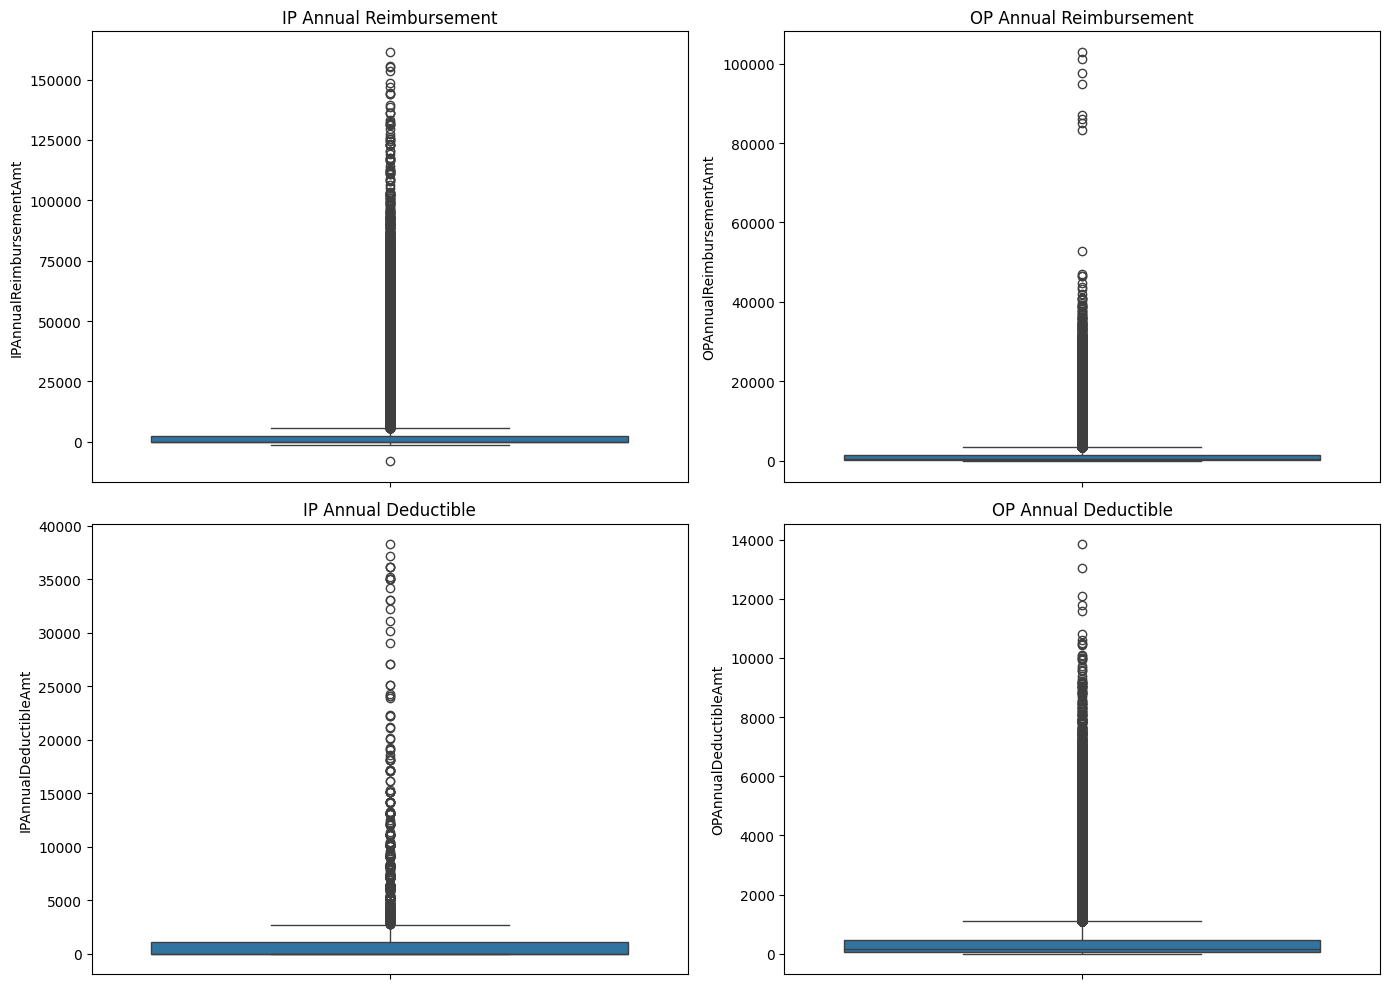

In [128]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(y=beneficiary_df['IPAnnualReimbursementAmt'], ax=axes[0, 0])
axes[0, 0].set_title('IP Annual Reimbursement')

sns.boxplot(y=beneficiary_df['OPAnnualReimbursementAmt'], ax=axes[0, 1])
axes[0, 1].set_title('OP Annual Reimbursement')

sns.boxplot(y=beneficiary_df['IPAnnualDeductibleAmt'], ax=axes[1, 0])
axes[1, 0].set_title('IP Annual Deductible')

sns.boxplot(y=beneficiary_df['OPAnnualDeductibleAmt'], ax=axes[1, 1])
axes[1, 1].set_title('OP Annual Deductible')

plt.tight_layout()
plt.show()

In [129]:
for col in numeric_cols:
    print(f"\n{col}")
    print("Zero values:", (beneficiary_df[col] == 0).sum())


NoOfMonths_PartACov
Zero values: 1000

NoOfMonths_PartBCov
Zero values: 675

IPAnnualReimbursementAmt
Zero values: 102511

IPAnnualDeductibleAmt
Zero values: 102019

OPAnnualReimbursementAmt
Zero values: 4205

OPAnnualDeductibleAmt
Zero values: 13890


In [130]:
for col in numeric_cols:
    print(f"\n{col}")
    print("Zero values:", (beneficiary_df[col] == 0).sum())


NoOfMonths_PartACov
Zero values: 1000

NoOfMonths_PartBCov
Zero values: 675

IPAnnualReimbursementAmt
Zero values: 102511

IPAnnualDeductibleAmt
Zero values: 102019

OPAnnualReimbursementAmt
Zero values: 4205

OPAnnualDeductibleAmt
Zero values: 13890


In [131]:
beneficiary_df['DOB'] = pd.to_datetime(beneficiary_df['DOB'])
beneficiary_df['DOD'] = pd.to_datetime(beneficiary_df['DOD'])

print(beneficiary_df[['DOB', 'DOD']].dtypes)

DOB    datetime64[ns]
DOD    datetime64[ns]
dtype: object


In [132]:
print("DOB range:")
print(beneficiary_df['DOB'].min(), "to", beneficiary_df['DOB'].max())

print("\nDOD range:")
print(beneficiary_df['DOD'].min(), "to", beneficiary_df['DOD'].max())

DOB range:
1909-01-01 00:00:00 to 1983-12-01 00:00:00

DOD range:
2009-02-01 00:00:00 to 2009-12-01 00:00:00


In [133]:
print("DOD missing:", beneficiary_df['DOD'].isna().sum())
print("DOD available:", beneficiary_df['DOD'].notna().sum())

DOD missing: 137135
DOD available: 1421


In [134]:
reference_date = pd.Timestamp('2009-12-31')

beneficiary_df['Age'] = (
    (reference_date - beneficiary_df['DOB']).dt.days / 365.25
).astype(int)

beneficiary_df[['DOB', 'Age']].head(10)

,DOB,Age
0,1943-01-01,66
1,1936-09-01,73
2,1936-08-01,73
3,1922-07-01,87
4,1935-09-01,74
5,1976-09-01,33
6,1940-09-01,69
7,1934-02-01,75
8,1929-06-01,80
9,1936-07-01,73


In [135]:
print("Age range:", beneficiary_df['Age'].min(), "to", beneficiary_df['Age'].max())
print(beneficiary_df['Age'].describe())

Age range: 26 to 100
count    138556.000000
mean         73.128663
std          12.724354
min          26.000000
25%          68.000000
50%          74.000000
75%          81.000000
max         100.000000
Name: Age, dtype: float64


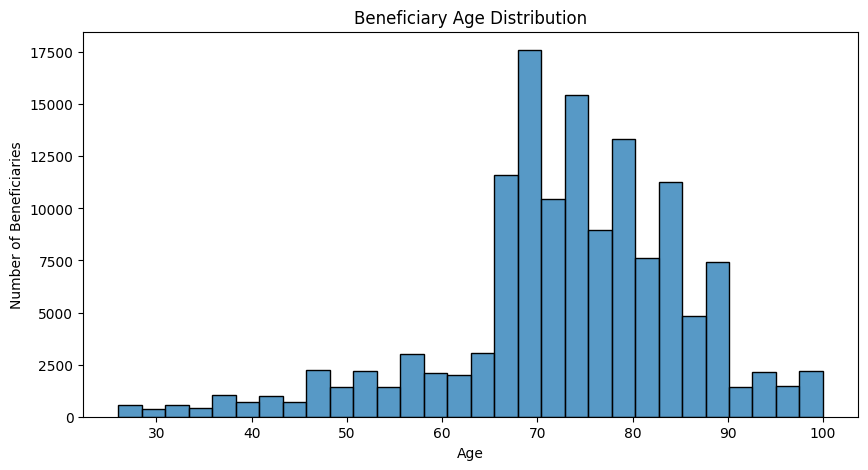

In [136]:
plt.figure(figsize=(10, 5))
sns.histplot(beneficiary_df['Age'], bins=30)
plt.title('Beneficiary Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Beneficiaries')
plt.show()

In [137]:
chronic_cols = [
    'ChronicCond_Alzheimer',
    'ChronicCond_Heartfailure',
    'ChronicCond_KidneyDisease',
    'ChronicCond_Cancer',
    'ChronicCond_ObstrPulmonary',
    'ChronicCond_Depression',
    'ChronicCond_Diabetes',
    'ChronicCond_IschemicHeart',
    'ChronicCond_Osteoporasis',
    'ChronicCond_rheumatoidarthritis',
    'ChronicCond_stroke'
]

print("Unique values across chronic condition columns:")

for col in chronic_cols:
    print(col, beneficiary_df[col].unique())

Unique values across chronic condition columns:
ChronicCond_Alzheimer [1 2]
ChronicCond_Heartfailure [2 1]
ChronicCond_KidneyDisease [1 2]
ChronicCond_Cancer [2 1]
ChronicCond_ObstrPulmonary [2 1]
ChronicCond_Depression [1 2]
ChronicCond_Diabetes [1 2]
ChronicCond_IschemicHeart [1 2]
ChronicCond_Osteoporasis [2 1]
ChronicCond_rheumatoidarthritis [1 2]
ChronicCond_stroke [1 2]


In [138]:
for col in chronic_cols:
    print(f"{col}:")
    print(beneficiary_df[col].value_counts().sort_index())
    print()

ChronicCond_Alzheimer:
ChronicCond_Alzheimer
1    46026
2    92530
Name: count, dtype: int64

ChronicCond_Heartfailure:
ChronicCond_Heartfailure
1    68402
2    70154
Name: count, dtype: int64

ChronicCond_KidneyDisease:
ChronicCond_KidneyDisease
1    43279
2    95277
Name: count, dtype: int64

ChronicCond_Cancer:
ChronicCond_Cancer
1     16621
2    121935
Name: count, dtype: int64

ChronicCond_ObstrPulmonary:
ChronicCond_ObstrPulmonary
1     32859
2    105697
Name: count, dtype: int64

ChronicCond_Depression:
ChronicCond_Depression
1    49260
2    89296
Name: count, dtype: int64

ChronicCond_Diabetes:
ChronicCond_Diabetes
1    83391
2    55165
Name: count, dtype: int64

ChronicCond_IschemicHeart:
ChronicCond_IschemicHeart
1    93644
2    44912
Name: count, dtype: int64

ChronicCond_Osteoporasis:
ChronicCond_Osteoporasis
1     38059
2    100497
Name: count, dtype: int64

ChronicCond_rheumatoidarthritis:
ChronicCond_rheumatoidarthritis
1     35584
2    102972
Name: count, dtype: int64



In [139]:
chronic_cols = [
    'ChronicCond_Alzheimer',
    'ChronicCond_Heartfailure',
    'ChronicCond_KidneyDisease',
    'ChronicCond_Cancer',
    'ChronicCond_ObstrPulmonary',
    'ChronicCond_Depression',
    'ChronicCond_Diabetes',
    'ChronicCond_IschemicHeart',
    'ChronicCond_Osteoporasis',
    'ChronicCond_rheumatoidarthritis',
    'ChronicCond_stroke'
]

beneficiary_df['ChronicConditionCount'] = (
    beneficiary_df[chronic_cols] == 1
).sum(axis=1)

beneficiary_df[['BeneID', 'ChronicConditionCount']].head(10)

,BeneID,ChronicConditionCount
0,BENE11001,7
1,BENE11002,0
2,BENE11003,2
3,BENE11004,6
4,BENE11005,2
5,BENE11006,0
6,BENE11007,5
7,BENE11008,1
8,BENE11009,2
9,BENE11010,6


In [140]:
print(beneficiary_df['ChronicConditionCount'].describe())

count    138556.000000
mean          3.739131
std           2.346638
min           0.000000
25%           2.000000
50%           4.000000
75%           5.000000
max          11.000000
Name: ChronicConditionCount, dtype: float64


In [141]:
print(
    beneficiary_df['ChronicConditionCount']
    .value_counts()
    .sort_index()
)

ChronicConditionCount
0     11276
1     16237
2     19440
3     20335
4     20146
5     17500
6     14363
7     10235
8      5892
9      2477
10      584
11       71
Name: count, dtype: int64


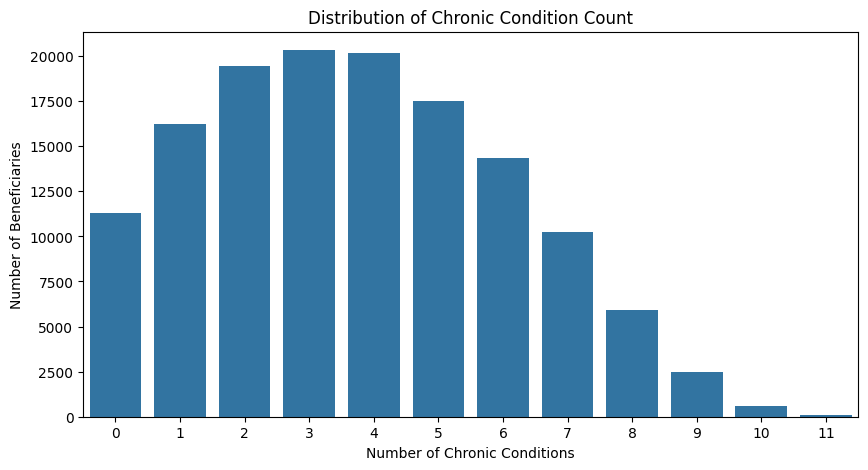

In [142]:
plt.figure(figsize=(10, 5))

sns.countplot(
    x=beneficiary_df['ChronicConditionCount']
)

plt.title('Distribution of Chronic Condition Count')
plt.xlabel('Number of Chronic Conditions')
plt.ylabel('Number of Beneficiaries')
plt.show()

In [143]:
beneficiary_df['TotalCoverageMonths'] = (
    beneficiary_df['NoOfMonths_PartACov'] +
    beneficiary_df['NoOfMonths_PartBCov']
)

beneficiary_df[
    ['BeneID', 'NoOfMonths_PartACov', 'NoOfMonths_PartBCov',
     'TotalCoverageMonths']
].head(10)

,BeneID,NoOfMonths_PartACov,NoOfMonths_PartBCov,TotalCoverageMonths
0,BENE11001,12,12,24
1,BENE11002,12,12,24
2,BENE11003,12,12,24
3,BENE11004,12,12,24
4,BENE11005,12,12,24
5,BENE11006,12,12,24
6,BENE11007,12,12,24
7,BENE11008,12,12,24
8,BENE11009,12,12,24
9,BENE11010,12,12,24


In [144]:
print(beneficiary_df['TotalCoverageMonths'].describe())

count    138556.000000
mean         23.817871
std           1.551719
min           0.000000
25%          24.000000
50%          24.000000
75%          24.000000
max          24.000000
Name: TotalCoverageMonths, dtype: float64


In [145]:
print(
    beneficiary_df['TotalCoverageMonths']
    .value_counts()
    .sort_index()
)

TotalCoverageMonths
0        175
1          6
2          5
3          2
4          3
5          3
6         47
7          5
8         10
9         13
10        19
11        31
12      1192
13        16
14        23
15        26
16        40
17        55
18       265
19        68
20        81
21       115
22       146
23       133
24    136077
Name: count, dtype: int64


In [146]:
beneficiary_df['TotalReimbursement'] = (
    beneficiary_df['IPAnnualReimbursementAmt'] +
    beneficiary_df['OPAnnualReimbursementAmt']
)

beneficiary_df[
    ['BeneID',
     'IPAnnualReimbursementAmt',
     'OPAnnualReimbursementAmt',
     'TotalReimbursement']
].head(10)

,BeneID,IPAnnualReimbursementAmt,OPAnnualReimbursementAmt,TotalReimbursement
0,BENE11001,36000,60,36060
1,BENE11002,0,30,30
2,BENE11003,0,90,90
3,BENE11004,0,1810,1810
4,BENE11005,0,1790,1790
5,BENE11006,0,500,500
6,BENE11007,0,1490,1490
7,BENE11008,0,30,30
8,BENE11009,0,100,100
9,BENE11010,0,1170,1170


In [147]:
beneficiary_df['TotalDeductible'] = (
    beneficiary_df['IPAnnualDeductibleAmt'] +
    beneficiary_df['OPAnnualDeductibleAmt']
)

beneficiary_df[
    ['BeneID',
     'IPAnnualDeductibleAmt',
     'OPAnnualDeductibleAmt',
     'TotalDeductible']
].head(10)

,BeneID,IPAnnualDeductibleAmt,OPAnnualDeductibleAmt,TotalDeductible
0,BENE11001,3204,70,3274
1,BENE11002,0,50,50
2,BENE11003,0,40,40
3,BENE11004,0,760,760
4,BENE11005,0,1200,1200
5,BENE11006,0,0,0
6,BENE11007,0,160,160
7,BENE11008,0,0,0
8,BENE11009,0,0,0
9,BENE11010,0,660,660


In [148]:
print("Total Reimbursement:")
print(beneficiary_df['TotalReimbursement'].describe())

print("\nTotal Deductible:")
print(beneficiary_df['TotalDeductible'].describe())

Total Reimbursement:
count    138556.000000
mean       4958.565851
std       10236.889587
min       -8000.000000
25%         270.000000
50%        1040.000000
75%        4690.000000
max      262720.000000
Name: TotalReimbursement, dtype: float64

Total Deductible:
count    138556.000000
mean        777.565555
std        1211.359681
min           0.000000
25%          80.000000
50%         320.000000
75%        1128.000000
max       40694.000000
Name: TotalDeductible, dtype: float64


In [149]:
beneficiary_df['TotalHealthcareCost'] = (
    beneficiary_df['TotalReimbursement'] +
    beneficiary_df['TotalDeductible']
)

beneficiary_df[
    ['BeneID',
     'TotalReimbursement',
     'TotalDeductible',
     'TotalHealthcareCost']
].head(10)

,BeneID,TotalReimbursement,TotalDeductible,TotalHealthcareCost
0,BENE11001,36060,3274,39334
1,BENE11002,30,50,80
2,BENE11003,90,40,130
3,BENE11004,1810,760,2570
4,BENE11005,1790,1200,2990
5,BENE11006,500,0,500
6,BENE11007,1490,160,1650
7,BENE11008,30,0,30
8,BENE11009,100,0,100
9,BENE11010,1170,660,1830


In [150]:
print(beneficiary_df['TotalHealthcareCost'].describe())

count    138556.000000
mean       5736.131405
std       11056.617671
min       -6902.000000
25%         420.000000
50%        1450.000000
75%        5938.000000
max      265721.000000
Name: TotalHealthcareCost, dtype: float64


In [151]:
print(
    "Negative TotalHealthcareCost:",
    (beneficiary_df['TotalHealthcareCost'] < 0).sum()
)

Negative TotalHealthcareCost: 1


In [152]:
beneficiary_df['ReimbursementPerCoverageMonth'] = (
    beneficiary_df['TotalReimbursement'] /
    beneficiary_df['TotalCoverageMonths'].replace(0, np.nan)
)

In [153]:
print(
    beneficiary_df['ReimbursementPerCoverageMonth'].describe()
)

count    138381.000000
mean        209.005753
std         435.708334
min        -333.333333
25%          11.250000
50%          43.750000
75%         196.666667
max       14000.000000
Name: ReimbursementPerCoverageMonth, dtype: float64


In [154]:
beneficiary_df['DeductiblePerCoverageMonth'] = (
    beneficiary_df['TotalDeductible'] /
    beneficiary_df['TotalCoverageMonths'].replace(0, np.nan)
)

In [155]:
print(
    beneficiary_df['DeductiblePerCoverageMonth'].describe()
)

count    138381.000000
mean         32.747135
std          51.286222
min           0.000000
25%           3.333333
50%          13.333333
75%          47.416667
max        1695.583333
Name: DeductiblePerCoverageMonth, dtype: float64


In [156]:
print(
    "Missing ReimbursementPerCoverageMonth:",
    beneficiary_df['ReimbursementPerCoverageMonth'].isna().sum()
)

print(
    "Missing DeductiblePerCoverageMonth:",
    beneficiary_df['DeductiblePerCoverageMonth'].isna().sum()
)

Missing ReimbursementPerCoverageMonth: 175
Missing DeductiblePerCoverageMonth: 175


In [157]:
beneficiary_df['IPReimbursementRatio'] = (
    beneficiary_df['IPAnnualReimbursementAmt'] /
    beneficiary_df['TotalReimbursement'].replace(0, np.nan)
)

In [158]:
beneficiary_df['OPReimbursementRatio'] = (
    beneficiary_df['OPAnnualReimbursementAmt'] /
    beneficiary_df['TotalReimbursement'].replace(0, np.nan)
)

In [159]:
print(beneficiary_df[
    ['IPReimbursementRatio', 'OPReimbursementRatio']
].describe())

       IPReimbursementRatio  OPReimbursementRatio
count         137670.000000         137670.000000
mean               0.228994              0.771006
std                0.393309              0.393309
min               -2.800000             -2.333333
25%                0.000000              0.486370
50%                0.000000              1.000000
75%                0.513630              1.000000
max                3.333333              3.800000


In [160]:
print("Zero TotalReimbursement:",
      (beneficiary_df['TotalReimbursement'] == 0).sum())

print("Negative TotalReimbursement:",
      (beneficiary_df['TotalReimbursement'] < 0).sum())

print("IP ratio < 0:",
      (beneficiary_df['IPReimbursementRatio'] < 0).sum())

print("IP ratio > 1:",
      (beneficiary_df['IPReimbursementRatio'] > 1).sum())

print("OP ratio < 0:",
      (beneficiary_df['OPReimbursementRatio'] < 0).sum())

print("OP ratio > 1:",
      (beneficiary_df['OPReimbursementRatio'] > 1).sum())

Zero TotalReimbursement: 886
Negative TotalReimbursement: 6
IP ratio < 0: 9
IP ratio > 1: 15
OP ratio < 0: 15
OP ratio > 1: 9


In [161]:
beneficiary_df.drop(
    columns=['IPReimbursementRatio', 'OPReimbursementRatio'],
    inplace=True
)

In [162]:
zero_coverage = beneficiary_df[
    beneficiary_df['TotalCoverageMonths'] == 0
]

print("Zero coverage beneficiaries:", len(zero_coverage))

print("\nTheir reimbursement:")
print(zero_coverage['TotalReimbursement'].describe())

print("\nTheir deductible:")
print(zero_coverage['TotalDeductible'].describe())

Zero coverage beneficiaries: 175

Their reimbursement:
count      175.000000
mean      5216.914286
std      12138.620027
min          0.000000
25%        110.000000
50%        590.000000
75%       3995.000000
max      80300.000000
Name: TotalReimbursement, dtype: float64

Their deductible:
count     175.000000
mean      612.777143
std      1009.730106
min         0.000000
25%        20.000000
50%       120.000000
75%      1068.000000
max      6668.000000
Name: TotalDeductible, dtype: float64


In [163]:
zero_coverage[
    [
        'BeneID',
        'NoOfMonths_PartACov',
        'NoOfMonths_PartBCov',
        'TotalCoverageMonths',
        'TotalReimbursement',
        'TotalDeductible',
        'ReimbursementPerCoverageMonth',
        'DeductiblePerCoverageMonth'
    ]
].head(20)

,BeneID,NoOfMonths_PartACov,NoOfMonths_PartBCov,TotalCoverageMonths,TotalReimbursement,TotalDeductible,ReimbursementPerCoverageMonth,DeductiblePerCoverageMonth
1088,BENE12155,0,0,0,2090,370,NaN,NaN
1234,BENE12310,0,0,0,32000,1068,NaN,NaN
2823,BENE14006,0,0,0,90,0,NaN,NaN
3100,BENE14305,0,0,0,4070,3068,NaN,NaN
3104,BENE14309,0,0,0,780,240,NaN,NaN
3590,BENE14826,0,0,0,10110,1168,NaN,NaN
3672,BENE14916,0,0,0,17000,1068,NaN,NaN
4036,BENE15305,0,0,0,480,220,NaN,NaN
4149,BENE15431,0,0,0,1980,1260,NaN,NaN
4211,BENE15496,0,0,0,57370,2158,NaN,NaN


In [164]:
beneficiary_df['ZeroCoverageFlag'] = (
    beneficiary_df['TotalCoverageMonths'] == 0
).astype(int)

In [165]:
print(beneficiary_df['ZeroCoverageFlag'].value_counts())

ZeroCoverageFlag
0    138381
1       175
Name: count, dtype: int64


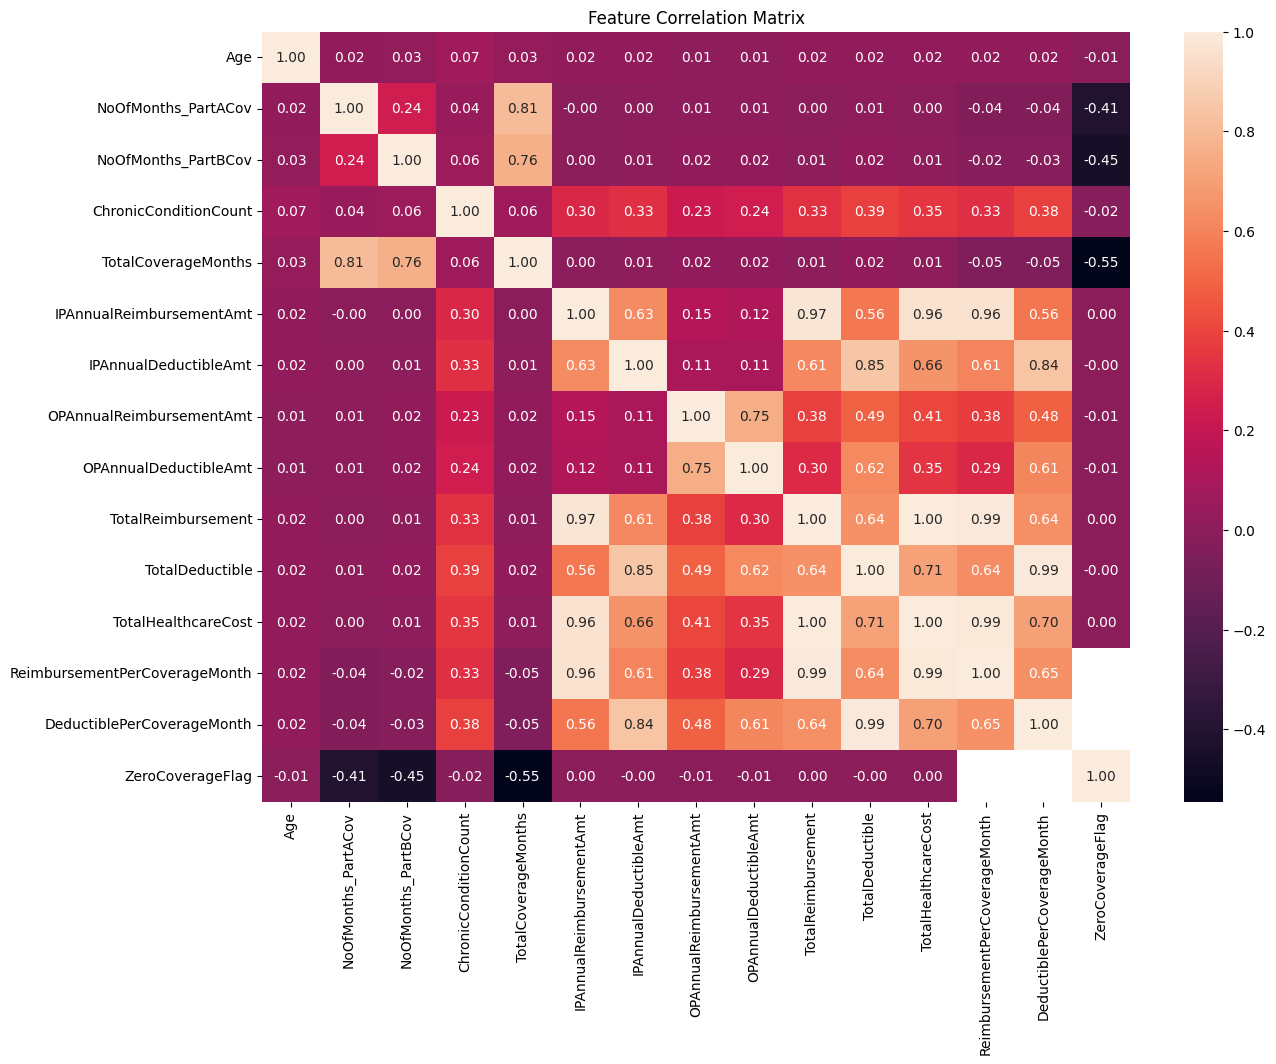

In [166]:
numeric_features = [
    'Age',
    'NoOfMonths_PartACov',
    'NoOfMonths_PartBCov',
    'ChronicConditionCount',
    'TotalCoverageMonths',
    'IPAnnualReimbursementAmt',
    'IPAnnualDeductibleAmt',
    'OPAnnualReimbursementAmt',
    'OPAnnualDeductibleAmt',
    'TotalReimbursement',
    'TotalDeductible',
    'TotalHealthcareCost',
    'ReimbursementPerCoverageMonth',
    'DeductiblePerCoverageMonth',
    'ZeroCoverageFlag'
]

correlation_matrix = beneficiary_df[numeric_features].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()

In [167]:
corr_pairs = (
    correlation_matrix
    .where(
        np.triu(
            np.ones(correlation_matrix.shape),
            k=1
        ).astype(bool)
    )
    .stack()
    .sort_values(ascending=False)
)

print("Highly correlated feature pairs (|correlation| >= 0.80):")

for (feature1, feature2), correlation in corr_pairs.items():
    if abs(correlation) >= 0.80:
        print(
            f"{feature1} <-> {feature2}: "
            f"{correlation:.2f}"
        )

Highly correlated feature pairs (|correlation| >= 0.80):
TotalReimbursement <-> TotalHealthcareCost: 1.00
TotalDeductible <-> DeductiblePerCoverageMonth: 0.99
TotalReimbursement <-> ReimbursementPerCoverageMonth: 0.99
TotalHealthcareCost <-> ReimbursementPerCoverageMonth: 0.99
IPAnnualReimbursementAmt <-> TotalReimbursement: 0.97
IPAnnualReimbursementAmt <-> ReimbursementPerCoverageMonth: 0.96
IPAnnualReimbursementAmt <-> TotalHealthcareCost: 0.96
IPAnnualDeductibleAmt <-> TotalDeductible: 0.85
IPAnnualDeductibleAmt <-> DeductiblePerCoverageMonth: 0.84
NoOfMonths_PartACov <-> TotalCoverageMonths: 0.81


In [168]:
beneficiary_df['DeceasedFlag'] = (
    beneficiary_df['DOD'].notna()
).astype(int)

print(beneficiary_df['DeceasedFlag'].value_counts())

DeceasedFlag
0    137135
1      1421
Name: count, dtype: int64


In [169]:
print(
    beneficiary_df.groupby('DeceasedFlag')['Age'].describe()
)

                 count       mean        std   min   25%   50%   75%    max
DeceasedFlag                                                               
0             137135.0  73.114478  12.743206  26.0  68.0  74.0  81.0  100.0
1               1421.0  74.497537  10.665835  36.0  68.0  75.0  82.0  100.0


In [170]:
print(beneficiary_df.dtypes)

BeneID                                     object
DOB                                datetime64[ns]
DOD                                datetime64[ns]
Gender                                      int64
Race                                        int64
RenalDiseaseIndicator                      object
State                                       int64
County                                      int64
NoOfMonths_PartACov                         int64
NoOfMonths_PartBCov                         int64
ChronicCond_Alzheimer                       int64
ChronicCond_Heartfailure                    int64
ChronicCond_KidneyDisease                   int64
ChronicCond_Cancer                          int64
ChronicCond_ObstrPulmonary                  int64
ChronicCond_Depression                      int64
ChronicCond_Diabetes                        int64
ChronicCond_IschemicHeart                   int64
ChronicCond_Osteoporasis                    int64
ChronicCond_rheumatoidarthritis             int64


In [171]:
print("\nObject columns:")
print(beneficiary_df.select_dtypes(include='object').columns.tolist())

print("\nNumeric columns:")
print(beneficiary_df.select_dtypes(include='number').columns.tolist())


Object columns:
['BeneID', 'RenalDiseaseIndicator']

Numeric columns:
['Gender', 'Race', 'State', 'County', 'NoOfMonths_PartACov', 'NoOfMonths_PartBCov', 'ChronicCond_Alzheimer', 'ChronicCond_Heartfailure', 'ChronicCond_KidneyDisease', 'ChronicCond_Cancer', 'ChronicCond_ObstrPulmonary', 'ChronicCond_Depression', 'ChronicCond_Diabetes', 'ChronicCond_IschemicHeart', 'ChronicCond_Osteoporasis', 'ChronicCond_rheumatoidarthritis', 'ChronicCond_stroke', 'IPAnnualReimbursementAmt', 'IPAnnualDeductibleAmt', 'OPAnnualReimbursementAmt', 'OPAnnualDeductibleAmt', 'Age', 'ChronicConditionCount', 'TotalCoverageMonths', 'TotalReimbursement', 'TotalDeductible', 'TotalHealthcareCost', 'ReimbursementPerCoverageMonth', 'DeductiblePerCoverageMonth', 'ZeroCoverageFlag', 'DeceasedFlag']


In [172]:
categorical_cols = [
    'Gender',
    'Race',
    'RenalDiseaseIndicator',
    'State',
    'County'
]

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print("Unique values:", beneficiary_df[col].nunique())
    print("Values:", sorted(beneficiary_df[col].unique())[:20])


--- Gender ---
Unique values: 2
Values: [np.int64(1), np.int64(2)]

--- Race ---
Unique values: 4
Values: [np.int64(1), np.int64(2), np.int64(3), np.int64(5)]

--- RenalDiseaseIndicator ---
Unique values: 2
Values: ['0', 'Y']

--- State ---
Unique values: 52
Values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]

--- County ---
Unique values: 314
Values: [np.int64(0), np.int64(1), np.int64(10), np.int64(11), np.int64(14), np.int64(20), np.int64(25), np.int64(30), np.int64(34), np.int64(40), np.int64(50), np.int64(55), np.int64(60), np.int64(70), np.int64(80), np.int64(84), np.int64(88), np.int64(90), np.int64(100), np.int64(110)]


In [173]:
beneficiary_df['RenalDiseaseFlag'] = (
    beneficiary_df['RenalDiseaseIndicator'] == 'Y'
).astype(int)

print(beneficiary_df['RenalDiseaseFlag'].value_counts())

RenalDiseaseFlag
0    118978
1     19578
Name: count, dtype: int64


In [174]:
beneficiary_df['GenderFlag'] = (
    beneficiary_df['Gender'] == 2
).astype(int)

print(beneficiary_df['GenderFlag'].value_counts())

GenderFlag
1    79106
0    59450
Name: count, dtype: int64


In [175]:
print(beneficiary_df['Race'].value_counts().sort_index())

Race
1    117057
2     13538
3      5059
5      2902
Name: count, dtype: int64


In [176]:
race_encoded = pd.get_dummies(
    beneficiary_df['Race'],
    prefix='Race',
    dtype=int
)

beneficiary_df = pd.concat(
    [beneficiary_df, race_encoded],
    axis=1
)

print(
    beneficiary_df[
        ['Race', 'Race_1', 'Race_2', 'Race_3', 'Race_5']
    ].head(10)
)

   Race  Race_1  Race_2  Race_3  Race_5
0     1       1       0       0       0
1     1       1       0       0       0
2     1       1       0       0       0
3     1       1       0       0       0
4     1       1       0       0       0
5     1       1       0       0       0
6     2       0       1       0       0
7     1       1       0       0       0
8     1       1       0       0       0
9     1       1       0       0       0


In [177]:
print("\nRace encoded columns:")
print(
    beneficiary_df[
        ['Race_1', 'Race_2', 'Race_3', 'Race_5']
    ].sum()
)


Race encoded columns:
Race_1    117057
Race_2     13538
Race_3      5059
Race_5      2902
dtype: int64


In [178]:
print(beneficiary_df['State'].value_counts().sort_index())

State
1      2615
2       196
3      2395
4      1817
5     12052
6      1807
7      1602
8       415
9       214
10     9771
11     3892
12      484
13      687
14     5923
15     3272
16     1746
17     1339
18     2519
19     1998
20      931
21     2570
22     3306
23     5293
24     2165
25     1622
26     3108
27      538
28      905
29      752
30      732
31     4124
32      895
33     8443
34     4629
35      304
36     5366
37     1926
38     1468
39     6055
41      438
42     2524
43      465
44     3390
45     8780
46      851
47      410
49     3623
50     2793
51     1212
52     2662
53      295
54     1237
Name: count, dtype: int64


In [179]:
state_encoded = pd.get_dummies(
    beneficiary_df['State'],
    prefix='State',
    dtype=int
)

beneficiary_df = pd.concat(
    [beneficiary_df, state_encoded],
    axis=1
)

print(
    beneficiary_df[
        ['State'] + list(state_encoded.columns)
    ].head()
)

   State  State_1  State_2  State_3  State_4  State_5  State_6  State_7  \
0     39        0        0        0        0        0        0        0   
1     39        0        0        0        0        0        0        0   
2     52        0        0        0        0        0        0        0   
3     39        0        0        0        0        0        0        0   
4     24        0        0        0        0        0        0        0   

   State_8  State_9  ...  State_44  State_45  State_46  State_47  State_49  \
0        0        0  ...         0         0         0         0         0   
1        0        0  ...         0         0         0         0         0   
2        0        0  ...         0         0         0         0         0   
3        0        0  ...         0         0         0         0         0   
4        0        0  ...         0         0         0         0         0   

   State_50  State_51  State_52  State_53  State_54  
0         0         0     

In [180]:
print("Number of State encoded columns:", len(state_encoded.columns))
print(state_encoded.sum().sort_index())

Number of State encoded columns: 52
State_1      2615
State_10     9771
State_11     3892
State_12      484
State_13      687
State_14     5923
State_15     3272
State_16     1746
State_17     1339
State_18     2519
State_19     1998
State_2       196
State_20      931
State_21     2570
State_22     3306
State_23     5293
State_24     2165
State_25     1622
State_26     3108
State_27      538
State_28      905
State_29      752
State_3      2395
State_30      732
State_31     4124
State_32      895
State_33     8443
State_34     4629
State_35      304
State_36     5366
State_37     1926
State_38     1468
State_39     6055
State_4      1817
State_41      438
State_42     2524
State_43      465
State_44     3390
State_45     8780
State_46      851
State_47      410
State_49     3623
State_5     12052
State_50     2793
State_51     1212
State_52     2662
State_53      295
State_54     1237
State_6      1807
State_7      1602
State_8       415
State_9       214
dtype: int64


In [181]:
county_frequency = beneficiary_df['County'].value_counts()

beneficiary_df['CountyFrequency'] = (
    beneficiary_df['County'].map(county_frequency)
)

beneficiary_df[
    ['County', 'CountyFrequency']
].head(10)

,County,CountyFrequency
0,230,1259
1,280,1423
2,590,2068
3,270,1482
4,680,650
5,810,1547
6,610,1913
7,140,1346
8,230,1259
9,30,1651


In [182]:
print(beneficiary_df['CountyFrequency'].describe())

count    138556.000000
mean       1728.523759
std         904.799444
min           1.000000
25%        1153.000000
50%        1651.000000
75%        2231.000000
max        3943.000000
Name: CountyFrequency, dtype: float64


In [183]:
print(
    beneficiary_df[
        ['County', 'CountyFrequency']
    ].drop_duplicates().sort_values('CountyFrequency').head(10)
)

        County  CountyFrequency
130365     521                1
128965     744                1
128794     944                1
29464      753                1
11812      834                1
69951      117                1
110399     796                1
105539     742                1
44462      804                1
7788       912                2


In [184]:
beneficiary_df['CountyRarity'] = (
    1 / beneficiary_df['CountyFrequency']
)

print(beneficiary_df['CountyRarity'].describe())

count    138556.000000
mean          0.002266
std           0.014953
min           0.000254
25%           0.000448
50%           0.000606
75%           0.000867
max           1.000000
Name: CountyRarity, dtype: float64


In [185]:
beneficiary_df['CountyRarity'] = (
    1 / beneficiary_df['CountyFrequency']
)

print(beneficiary_df['CountyRarity'].describe())

count    138556.000000
mean          0.002266
std           0.014953
min           0.000254
25%           0.000448
50%           0.000606
75%           0.000867
max           1.000000
Name: CountyRarity, dtype: float64


In [186]:
print("Total columns:", len(beneficiary_df.columns))

print("\nAll columns:")
for i, col in enumerate(beneficiary_df.columns, 1):
    print(i, col)

Total columns: 95

All columns:
1 BeneID
2 DOB
3 DOD
4 Gender
5 Race
6 RenalDiseaseIndicator
7 State
8 County
9 NoOfMonths_PartACov
10 NoOfMonths_PartBCov
11 ChronicCond_Alzheimer
12 ChronicCond_Heartfailure
13 ChronicCond_KidneyDisease
14 ChronicCond_Cancer
15 ChronicCond_ObstrPulmonary
16 ChronicCond_Depression
17 ChronicCond_Diabetes
18 ChronicCond_IschemicHeart
19 ChronicCond_Osteoporasis
20 ChronicCond_rheumatoidarthritis
21 ChronicCond_stroke
22 IPAnnualReimbursementAmt
23 IPAnnualDeductibleAmt
24 OPAnnualReimbursementAmt
25 OPAnnualDeductibleAmt
26 Age
27 ChronicConditionCount
28 TotalCoverageMonths
29 TotalReimbursement
30 TotalDeductible
31 TotalHealthcareCost
32 ReimbursementPerCoverageMonth
33 DeductiblePerCoverageMonth
34 ZeroCoverageFlag
35 DeceasedFlag
36 RenalDiseaseFlag
37 GenderFlag
38 Race_1
39 Race_2
40 Race_3
41 Race_5
42 State_1
43 State_2
44 State_3
45 State_4
46 State_5
47 State_6
48 State_7
49 State_8
50 State_9
51 State_10
52 State_11
53 State_12
54 State_13
55

In [187]:
engineered_features = [
    'Age',
    'ChronicConditionCount',
    'TotalCoverageMonths',
    'TotalReimbursement',
    'TotalDeductible',
    'TotalHealthcareCost',
    'ReimbursementPerCoverageMonth',
    'DeductiblePerCoverageMonth',
    'ZeroCoverageFlag',
    'DeceasedFlag',
    'RenalDiseaseFlag',
    'GenderFlag',
    'CountyFrequency',
    'CountyRarity'
]

print(beneficiary_df[engineered_features].head())

   Age  ChronicConditionCount  TotalCoverageMonths  TotalReimbursement  \
0   66                      7                   24               36060   
1   73                      0                   24                  30   
2   73                      2                   24                  90   
3   87                      6                   24                1810   
4   74                      2                   24                1790   

   TotalDeductible  TotalHealthcareCost  ReimbursementPerCoverageMonth  \
0             3274                39334                    1502.500000   
1               50                   80                       1.250000   
2               40                  130                       3.750000   
3              760                 2570                      75.416667   
4             1200                 2990                      74.583333   

   DeductiblePerCoverageMonth  ZeroCoverageFlag  DeceasedFlag  \
0                  136.416667                

In [188]:
print(
    beneficiary_df[engineered_features]
    .isnull()
    .sum()
    .sort_values(ascending=False)
)

DeductiblePerCoverageMonth       175
ReimbursementPerCoverageMonth    175
TotalCoverageMonths                0
TotalReimbursement                 0
Age                                0
ChronicConditionCount              0
TotalHealthcareCost                0
TotalDeductible                    0
ZeroCoverageFlag                   0
DeceasedFlag                       0
RenalDiseaseFlag                   0
GenderFlag                         0
CountyFrequency                    0
CountyRarity                       0
dtype: int64


In [189]:
beneficiary_df['ReimbursementPerCoverageMonth_Missing'] = (
    beneficiary_df['ReimbursementPerCoverageMonth'].isna()
).astype(int)

beneficiary_df['DeductiblePerCoverageMonth_Missing'] = (
    beneficiary_df['DeductiblePerCoverageMonth'].isna()
).astype(int)

In [190]:
print(
    beneficiary_df[
        [
            'ReimbursementPerCoverageMonth_Missing',
            'DeductiblePerCoverageMonth_Missing'
        ]
    ].sum()
)

ReimbursementPerCoverageMonth_Missing    175
DeductiblePerCoverageMonth_Missing       175
dtype: int64


In [191]:
beneficiary_df['ReimbursementPerCoverageMonth'] = (
    beneficiary_df['ReimbursementPerCoverageMonth'].fillna(0)
)

beneficiary_df['DeductiblePerCoverageMonth'] = (
    beneficiary_df['DeductiblePerCoverageMonth'].fillna(0)
)

In [192]:
print(
    beneficiary_df[
        [
            'ReimbursementPerCoverageMonth',
            'DeductiblePerCoverageMonth'
        ]
    ].isnull().sum()
)

ReimbursementPerCoverageMonth    0
DeductiblePerCoverageMonth       0
dtype: int64


In [193]:
financial_cols = [
    'IPAnnualReimbursementAmt',
    'IPAnnualDeductibleAmt',
    'OPAnnualReimbursementAmt',
    'OPAnnualDeductibleAmt',
    'TotalReimbursement',
    'TotalDeductible',
    'TotalHealthcareCost'
]

for col in financial_cols:
    print(
        col,
        "negative values:",
        (beneficiary_df[col] < 0).sum()
    )

IPAnnualReimbursementAmt negative values: 15
IPAnnualDeductibleAmt negative values: 0
OPAnnualReimbursementAmt negative values: 12
OPAnnualDeductibleAmt negative values: 0
TotalReimbursement negative values: 6
TotalDeductible negative values: 0
TotalHealthcareCost negative values: 1


In [194]:
numeric_cols = beneficiary_df.select_dtypes(
    include=np.number
).columns

print(
    "Positive infinity:",
    np.isposinf(beneficiary_df[numeric_cols]).sum().sum()
)

print(
    "Negative infinity:",
    np.isneginf(beneficiary_df[numeric_cols]).sum().sum()
)

Positive infinity: 0
Negative infinity: 0


In [195]:
missing_summary = (
    beneficiary_df.isnull()
    .sum()
    .sort_values(ascending=False)
)

print(missing_summary[missing_summary > 0])

DOD    137135
dtype: int64


In [196]:
beneficiary_df = beneficiary_df.drop(
    columns=['DOB', 'DOD']
)

print("DOB and DOD removed successfully.")
print("Current shape:", beneficiary_df.shape)

DOB and DOD removed successfully.
Current shape: (138556, 95)


In [197]:
print(
    beneficiary_df.isnull().sum().sum()
)

0


In [198]:
print("Duplicate rows:", beneficiary_df.duplicated().sum())
print("Duplicate BeneID:", beneficiary_df['BeneID'].duplicated().sum())

Duplicate rows: 0
Duplicate BeneID: 0


In [199]:
print(beneficiary_df.dtypes)

BeneID                                    object
Gender                                     int64
Race                                       int64
RenalDiseaseIndicator                     object
State                                      int64
                                          ...   
State_54                                   int64
CountyFrequency                            int64
CountyRarity                             float64
ReimbursementPerCoverageMonth_Missing      int64
DeductiblePerCoverageMonth_Missing         int64
Length: 95, dtype: object


In [200]:
print("\nObject columns:")
print(beneficiary_df.select_dtypes(include='object').columns.tolist())

print("\nNumeric columns:")
print(beneficiary_df.select_dtypes(include=np.number).columns.tolist())


Object columns:
['BeneID', 'RenalDiseaseIndicator']

Numeric columns:
['Gender', 'Race', 'State', 'County', 'NoOfMonths_PartACov', 'NoOfMonths_PartBCov', 'ChronicCond_Alzheimer', 'ChronicCond_Heartfailure', 'ChronicCond_KidneyDisease', 'ChronicCond_Cancer', 'ChronicCond_ObstrPulmonary', 'ChronicCond_Depression', 'ChronicCond_Diabetes', 'ChronicCond_IschemicHeart', 'ChronicCond_Osteoporasis', 'ChronicCond_rheumatoidarthritis', 'ChronicCond_stroke', 'IPAnnualReimbursementAmt', 'IPAnnualDeductibleAmt', 'OPAnnualReimbursementAmt', 'OPAnnualDeductibleAmt', 'Age', 'ChronicConditionCount', 'TotalCoverageMonths', 'TotalReimbursement', 'TotalDeductible', 'TotalHealthcareCost', 'ReimbursementPerCoverageMonth', 'DeductiblePerCoverageMonth', 'ZeroCoverageFlag', 'DeceasedFlag', 'RenalDiseaseFlag', 'GenderFlag', 'Race_1', 'Race_2', 'Race_3', 'Race_5', 'State_1', 'State_2', 'State_3', 'State_4', 'State_5', 'State_6', 'State_7', 'State_8', 'State_9', 'State_10', 'State_11', 'State_12', 'State_13', 'S

In [201]:
columns_to_remove = [
    'RenalDiseaseIndicator',
    'Gender',
    'Race',
    'State',
    'County'
]

beneficiary_df = beneficiary_df.drop(
    columns=columns_to_remove
)

print("Removed redundant original categorical columns.")
print("Final shape:", beneficiary_df.shape)

Removed redundant original categorical columns.
Final shape: (138556, 90)


In [202]:
print("========== FINAL VALIDATION ==========")

print("\nShape:")
print(beneficiary_df.shape)

print("\nMissing values:")
print(beneficiary_df.isnull().sum().sum())

print("\nDuplicate rows:")
print(beneficiary_df.duplicated().sum())

print("\nDuplicate BeneID:")
print(beneficiary_df['BeneID'].duplicated().sum())

print("\nInfinite values:")
numeric_cols = beneficiary_df.select_dtypes(include=np.number).columns
print(np.isinf(beneficiary_df[numeric_cols]).sum().sum())

print("\nData types:")
print(beneficiary_df.dtypes.value_counts())

print("\nBeneID unique:")
print(beneficiary_df['BeneID'].nunique())

========== FINAL VALIDATION ==========

Shape:
(138556, 90)

Missing values:
0

Duplicate rows:
0

Duplicate BeneID:
0

Infinite values:
0

Data types:
int64      86
float64     3
object      1
Name: count, dtype: int64

BeneID unique:
138556


In [205]:
beneficiary_df.to_csv(
    "/kaggle/working/beneficiary_preprocessed.csv",
    index=False
)

print("CSV saved!")

CSV saved!


In [206]:
import os

print(os.path.exists("/kaggle/working/beneficiary_preprocessed.csv"))

True
